In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

In [2]:
import os
os.listdir()

['.ipynb_checkpoints',
 'GBM_IC_Fri Feb 20 16_35_30 2026.csv',
 'GBM_TCGA',
 'GBM_TCGA.gz',
 'PANCANCER_Genetic_features_variant_Fri Feb 20 16_45_37 2026.csv',
 'Project (D3).ipynb',
 'trametinib_final_model.pkl']

In [3]:
import pandas as pd

mut_df = pd.read_csv("PANCANCER_Genetic_features_variant_Fri Feb 20 16_45_37 2026.csv")
ic50_df = pd.read_csv("GBM_IC_Fri Feb 20 16_35_30 2026.csv")

print("Mutation shape:", mut_df.shape)
print("IC50 shape:", ic50_df.shape)

Mutation shape: (288300, 9)
IC50 shape: (8432, 13)


In [4]:
print(ic50_df.columns)

Index(['Drug Name', 'Drug ID', 'Cell Line Name', 'Cosmic ID',
       'TCGA Classification', 'Tissue', 'Tissue Sub-type', 'IC50', 'AUC',
       'Max Conc', 'RMSE', 'Z score', 'Dataset Version'],
      dtype='object')


In [5]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

In [6]:
mut_df = pd.read_csv("PANCANCER_Genetic_features_variant_Fri Feb 20 16_45_37 2026.csv")
ic50_df = pd.read_csv("GBM_IC_Fri Feb 20 16_35_30 2026.csv")

print("Mutation shape:", mut_df.shape)
print("IC50 shape:", ic50_df.shape)

Mutation shape: (288300, 9)
IC50 shape: (8432, 13)


In [7]:
mut_gbm = mut_df[mut_df["TCGA Desc"] == "GBM"]

mut_pivot_gbm = mut_gbm.pivot_table(
    index="Cell Line Name",
    columns="Genetic Feature",
    values="IS Mutated",
    aggfunc="max",
    fill_value=0
)

print("GBM mutation matrix:", mut_pivot_gbm.shape)

GBM mutation matrix: (32, 310)


In [8]:
def analyze_drug(drug_name):
    
    print("\n==========", drug_name, "==========")
    
    # Filter for this drug (IC50 already GBM-specific)
    ic50_drug = ic50_df[ic50_df["Drug Name"] == drug_name]
    ic50_drug = ic50_drug[["Cell Line Name", "IC50"]]
    
    # Merge mutation + IC50
    df = mut_pivot_gbm.merge(
        ic50_drug,
        left_index=True,
        right_on="Cell Line Name",
        how="inner"
    )
    
    print("Samples:", df.shape[0])
    
    # Binary response (median split)
    median_ic50 = df["IC50"].median()
    df["Response"] = np.where(df["IC50"] < median_ic50, 1, 0)
    
    print("Class balance:")
    print(df["Response"].value_counts())
    
    # Feature reduction (>=3 mutations)
    X = df.drop(columns=["Cell Line Name", "IC50", "Response"])
    y = df["Response"]
    
    mutation_counts = X.sum(axis=0)
    selected_genes = mutation_counts[mutation_counts >= 3].index
    X_reduced = X[selected_genes]
    
    print("Reduced feature count:", X_reduced.shape[1])
    
    # Model
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    logreg = LogisticRegressionCV(
        cv=cv,
        penalty="l1",
        solver="liblinear",
        scoring="roc_auc",
        random_state=42
    )
    
    auc_scores = []
    
    for train_idx, test_idx in cv.split(X_reduced, y):
        logreg.fit(X_reduced.iloc[train_idx], y.iloc[train_idx])
        probs = logreg.predict_proba(X_reduced.iloc[test_idx])[:, 1]
        auc_scores.append(roc_auc_score(y.iloc[test_idx], probs))
    
    print("AUC scores:", auc_scores)
    print("Mean AUC:", np.mean(auc_scores))
    
    # Fit full model for interpretation
    logreg.fit(X_reduced, y)
    coef = logreg.coef_[0]
    
    gene_importance = pd.Series(coef, index=X_reduced.columns)
    gene_importance = gene_importance.sort_values(key=abs, ascending=False)
    
    print("\nTop genes:")
    print(gene_importance.head(10))
    
    return gene_importance

In [9]:
tram_genes = analyze_drug("Trametinib")
selu_genes = analyze_drug("Selumetinib")


========== Trametinib ==========
Samples: 32
Class balance:
Response
0    16
1    16
Name: count, dtype: int64
Reduced feature count: 4
AUC scores: [0.7083333333333333, 1.0, 0.6666666666666666, 1.0, 0.8333333333333334]
Mean AUC: 0.8416666666666666

Top genes:
RB1_mut    -10.937646
TP53_mut    -3.797458
PTEN_mut     2.427251
NF1_mut      0.341386
dtype: float64

========== Selumetinib ==========
Samples: 54
Class balance:
Response
0    27
1    27
Name: count, dtype: int64
Reduced feature count: 10


C:\Software\anaconda3\envs\drugAI\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Software\anaconda3\envs\drugAI\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


AUC scores: [0.5, 0.5, 0.5499999999999999, 0.45, 0.78]
Mean AUC: 0.5559999999999999

Top genes:
EGFR_mut     -1.573382
RB1_mut      -1.223426
TP53_mut     -1.057358
PTEN_mut      0.561625
CEP290_mut    0.320105
BRAF_mut      0.062384
PIK3CA_mut    0.000000
NF1_mut       0.000000
MLL3_mut      0.000000
STAG2_mut     0.000000
dtype: float64


In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

In [11]:
def build_dataset(drug_name):
    
    # Filter drug
    ic50_drug = ic50_df[ic50_df["Drug Name"] == drug_name]
    ic50_drug = ic50_drug[["Cell Line Name", "IC50"]]
    
    # Merge
    df = mut_pivot_gbm.merge(
        ic50_drug,
        left_index=True,
        right_on="Cell Line Name",
        how="inner"
    )
    
    # Binary response
    median_ic50 = df["IC50"].median()
    df["Response"] = np.where(df["IC50"] < median_ic50, 1, 0)
    
    # Features
    X = df.drop(columns=["Cell Line Name", "IC50", "Response"])
    y = df["Response"]
    
    # Keep genes mutated in ≥3 samples
    mutation_counts = X.sum(axis=0)
    selected_genes = mutation_counts[mutation_counts >= 3].index
    X = X[selected_genes]
    
    return X, y

In [12]:
X, y = build_dataset("Trametinib")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (24, 4)
Test size: (8, 4)


In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=5000
)

model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)

print("Test AUC:", auc)

Test AUC: 0.71875


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=3,
    random_state=42
)

rf.fit(X_train, y_train)

probs_rf = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, probs_rf)

print("Random Forest Test AUC:", auc_rf)

Random Forest Test AUC: 0.75


In [15]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

X, y = build_dataset("Trametinib")

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=20,
    random_state=42
)

model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=5000
)

auc_scores = []

for train_idx, test_idx in cv.split(X, y):
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    probs = model.predict_proba(X.iloc[test_idx])[:, 1]
    auc_scores.append(roc_auc_score(y.iloc[test_idx], probs))

print("Mean AUC:", np.mean(auc_scores))
print("Std AUC:", np.std(auc_scores))

Mean AUC: 0.8393055555555555
Std AUC: 0.17744385957949949


In [16]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
import pandas as pd
import numpy as np

X, y = build_dataset("Trametinib")

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=50, random_state=42)

selection_counts = pd.Series(0, index=X.columns)

for train_idx, test_idx in cv.split(X, y):
    model = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=5000
    )
    
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    
    selected = X.columns[model.coef_[0] != 0]
    selection_counts[selected] += 1

selection_freq = selection_counts / (5*50)

print(selection_freq.sort_values(ascending=False))

TP53_mut    1.000
PTEN_mut    0.940
RB1_mut     0.728
NF1_mut     0.556
dtype: float64


# Freeze Final Trametinib Model

# Build Dataset

In [17]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# Build dataset
X, y = build_dataset("Trametinib")

print("Samples:", X.shape[0])
print("Features:", X.shape[1])

Samples: 32
Features: 4


# Keep Only Stable Genes (Cleaner Model)

In [18]:
stable_genes = ["TP53_mut", "PTEN_mut", "RB1_mut", "NF1_mut"]

X_final = X[stable_genes]

# Train Final Model on Full Dataset 

In [19]:
final_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=5000
)

final_model.fit(X_final, y)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,5000
,multi_class,'deprecated'


# Evaluate Final AUC (On Full Data)

In [20]:
probs = final_model.predict_proba(X_final)[:, 1]
final_auc = roc_auc_score(y, probs)

print("Final Model AUC (full data):", final_auc)

Final Model AUC (full data): 0.908203125


# Extract Final Coefficients

In [21]:
coef_df = pd.Series(
    final_model.coef_[0],
    index=stable_genes
).sort_values(ascending=False)

print(coef_df)

PTEN_mut    0.931612
NF1_mut     0.061463
RB1_mut    -0.801335
TP53_mut   -1.907433
dtype: float64


# Save Model

In [22]:
import joblib

joblib.dump(final_model, "trametinib_final_model.pkl")

['trametinib_final_model.pkl']

In [23]:
import joblib

# Load model
loaded_model = joblib.load("trametinib_final_model.pkl")

# Predict again
probs_loaded = loaded_model.predict_proba(X_final)[:, 1]

print("Loaded model AUC:", roc_auc_score(y, probs_loaded))

Loaded model AUC: 0.908203125


# Create Stability Plot

In [24]:
import matplotlib.pyplot as plt
import matplotlib
print(matplotlib.__version__)

3.10.8


In [25]:
def build_dataset(drug_name):
    
    # Filter IC50 for the selected drug
    drug_data = ic50[ic50["Drug"] == drug_name]
    
    # Merge with mutation data
    merged = mutation.merge(drug_data, on="CellLine")
    
    # Create binary response (median split)
    median_ic50 = merged["IC50"].median()
    merged["Response"] = (merged["IC50"] < median_ic50).astype(int)
    
    # Features = mutation columns
    feature_cols = [col for col in mutation.columns if col.endswith("_mut")]
    
    X = merged[feature_cols]
    y = merged["Response"]
    
    return X, y

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import joblib

In [32]:
import os

folder = r"C:/Users/sofiya chavarekar/OneDrive/Desktop/AI-Driven Drug Response Project"
print(os.listdir(folder))

['.ipynb_checkpoints', 'GBM_IC_Fri Feb 20 16_35_30 2026.csv', 'GBM_TCGA', 'GBM_TCGA.gz', 'PANCANCER_Genetic_features_variant_Fri Feb 20 16_45_37 2026.csv', 'Project (D3).ipynb', 'trametinib_final_model.pkl']


In [2]:
import pandas as pd

mutation = pd.read_csv(
    r"C:/Users/sofiya chavarekar/OneDrive/Desktop/AI-Driven Drug Response Project/PANCANCER_Genetic_features_variant_Fri Feb 20 16_45_37 2026.csv"
)

ic50 = pd.read_csv(
    r"C:/Users/sofiya chavarekar/OneDrive/Desktop/AI-Driven Drug Response Project/GBM_IC_Fri Feb 20 16_35_30 2026.csv"
)

print("Mutation shape:", mutation.shape)
print("IC50 shape:", ic50.shape)

Mutation shape: (288300, 9)
IC50 shape: (8432, 13)


In [3]:
print(mutation.columns)

Index(['Cell Line Name', 'COSMIC ID', 'GDSC Desc1', 'GDSC Desc2', 'TCGA Desc',
       'Genetic Feature', 'IS Mutated', 'Recurrent Gain Loss',
       'Genes in Segment'],
      dtype='object')


In [4]:
# Keep only mutated rows
mutation_small = mutation[mutation["IS Mutated"] == 1].copy()

# Add mutation indicator
mutation_small["mut"] = 1

# Pivot to wide format
mutation_matrix = mutation_small.pivot_table(
    index="Cell Line Name",
    columns="Genetic Feature",
    values="mut",
    fill_value=0
)

# Rename columns
mutation_matrix.columns = [col + "_mut" for col in mutation_matrix.columns]

mutation_matrix.reset_index(inplace=True)

print("Mutation matrix shape:", mutation_matrix.shape)

Mutation matrix shape: (930, 310)


In [5]:
def build_dataset(drug_name):
    
    # Filter IC50 for selected drug
    drug_data = ic50[ic50["Drug Name"] == drug_name]
    drug_data = drug_data[["Cell Line Name", "IC50"]]
    
    # Merge with mutation matrix
    merged = mutation_matrix.merge(drug_data, on="Cell Line Name")
    
    # Binary response (median split)
    median_ic50 = merged["IC50"].median()
    merged["Response"] = (merged["IC50"] < median_ic50).astype(int)
    
    # Mutation features
    feature_cols = [col for col in merged.columns if col.endswith("_mut")]
    
    X = merged[feature_cols]
    y = merged["Response"]
    
    return X, y

In [6]:
X, y = build_dataset("Trametinib")

print("Samples:", X.shape[0])
print("Features:", X.shape[1])

Samples: 32
Features: 309


In [7]:
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=20, random_state=42)

aucs = []

for train_idx, test_idx in cv.split(X, y):
    
    model = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=5000
    )
    
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    
    probs = model.predict_proba(X.iloc[test_idx])[:, 1]
    auc = roc_auc_score(y.iloc[test_idx], probs)
    aucs.append(auc)

print("Mean AUC:", np.mean(aucs))
print("Std AUC:", np.std(aucs))

Mean AUC: 0.842638888888889
Std AUC: 0.17572661102117587


In [42]:
import pandas as pd

selection_counts = pd.Series(0, index=X.columns)

for train_idx, test_idx in cv.split(X, y):
    
    model = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=5000
    )
    
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    
    selected = X.columns[model.coef_[0] != 0]
    selection_counts[selected] += 1

selection_freq = selection_counts / len(aucs)

selection_freq.sort_values(ascending=False).head(10)

TP53_mut_mut       1.00
PTEN_mut_mut       0.96
RB1_mut_mut        0.73
NF1_mut_mut        0.54
CEP290_mut_mut     0.10
APC_mut_mut        0.00
AQR_mut_mut        0.00
ARAP3_mut_mut      0.00
ARFGAP3_mut_mut    0.00
ARFGEF1_mut_mut    0.00
dtype: float64

In [9]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

selection_counts = pd.Series(0, index=X.columns)

for train_idx, test_idx in cv.split(X, y):
    
    model = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        max_iter=5000
    )
    
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    
    selected = X.columns[model.coef_[0] != 0]
    selection_counts[selected] += 1

selection_freq = selection_counts / len(aucs)

selection_freq.sort_values(ascending=False).head(10)

TP53_mut_mut       1.00
PTEN_mut_mut       0.96
RB1_mut_mut        0.73
NF1_mut_mut        0.54
CEP290_mut_mut     0.11
APC_mut_mut        0.00
AQR_mut_mut        0.00
ARAP3_mut_mut      0.00
ARFGAP3_mut_mut    0.00
ARFGEF1_mut_mut    0.00
dtype: float64

In [10]:
stable_genes = selection_freq[selection_freq > 0.5].index.tolist()
print("Stable genes:", stable_genes)

Stable genes: ['NF1_mut_mut', 'PTEN_mut_mut', 'RB1_mut_mut', 'TP53_mut_mut']


In [11]:
# Clean names
clean_genes = [g.replace("_mut_mut", "") for g in stable_genes]
print(clean_genes)

['NF1', 'PTEN', 'RB1', 'TP53']


In [12]:
X_final = X[stable_genes].copy()
X_final.columns = clean_genes

from sklearn.linear_model import LogisticRegression

final_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=5000
)

final_model.fit(X_final, y)

,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,5000
,multi_class,'deprecated'


In [13]:
from sklearn.metrics import roc_auc_score

probs = final_model.predict_proba(X_final)[:, 1]
print("Final Training AUC:", roc_auc_score(y, probs))

Final Training AUC: 0.908203125


In [14]:
import pandas as pd

coef_df = pd.Series(
    final_model.coef_[0],
    index=clean_genes
).sort_values()

print(coef_df)

TP53   -1.907439
RB1    -0.801291
NF1     0.061495
PTEN    0.931588
dtype: float64


In [15]:
import joblib
joblib.dump(final_model, "trametinib_model.pkl")

['trametinib_model.pkl']

In [16]:
results_summary = {
    "Drug": "Trametinib",
    "Samples": X.shape[0],
    "Features": X.shape[1],
    "Stable Genes": clean_genes,
    "Final Training AUC": roc_auc_score(y, probs)
}

print(results_summary)

{'Drug': 'Trametinib', 'Samples': 32, 'Features': 309, 'Stable Genes': ['NF1', 'PTEN', 'RB1', 'TP53'], 'Final Training AUC': 0.908203125}


In [17]:
import json

with open("results_summary.json", "w") as f:
    json.dump(results_summary, f)

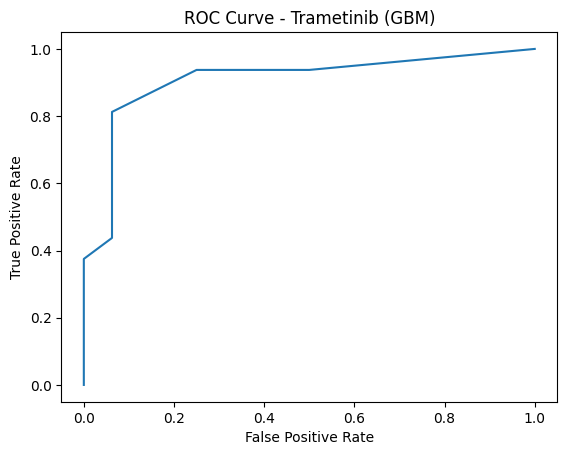

In [18]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y, probs)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Trametinib (GBM)")
plt.show()

In [19]:
from sklearn.model_selection import cross_val_score

cv_auc = cross_val_score(
    LogisticRegression(penalty="l1", solver="liblinear"),
    X_final,
    y,
    cv=5,
    scoring="roc_auc"
)

print("Mean CV AUC:", cv_auc.mean())
print("Std CV AUC:", cv_auc.std())

Mean CV AUC: 0.7555555555555555
Std CV AUC: 0.18227810796136573
